<a href="https://colab.research.google.com/github/samikshyasanskruti/DeepLearning-with-TesorFlow/blob/main/ASSIGNMENT_1(DLWTF_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBABILISTIC TENSORFLOW**

**SAMIKSHYA SANSKRUTI SWAIN**

**2341019634**


# **Q1. Central Tendency on List Data**


**(a) Create a Python list containing at least 10 numerical values and compute the mean, median,
and mode using NumPy and SciPy**

In [ ]:
import numpy as np
from scipy import stats

data=[10,20,30,40,50,20,30,60,70,80]

mean=np.mean(data)
median=np.median(data)
mode=stats.mode(data,keepdims=True)

print("Mean:",mean)
print("Median:",median)
print("Mode:",mode.mode[0])

Mean: 41.0
Median: 35.0
Mode: 20


***DISCUSSION***

*   Mean = average value
*   Median = middle value
*   Mode = most frequent value






**(b) Modify the dataset by adding extreme values (outliers), recalculate mean, median, and mode
and comment on which measure is most affected and why?**

In [ ]:
data_outlier=data+[500,600]

mean_outlier=np.mean(data_outlier)
median_outlier=np.median(data_outlier)
mode_outlier=stats.mode(data_outlier,keepdims=True)

print("Mean:",mean_outlier)
print("Median:",median_outlier)
print("Mode:",mode_outlier.mode)

Mean: 125.83333333333333
Median: 45.0
Mode: [20]


***DISCUSSION***


*  Mean changes significantly → sensitive to outliers
*   Median changes slightly → robust
*   Mode mostly unchanged



**(c) Write a Python program to sort the dataset and find the minimum, maximum, and range. Verify
the median manually**

In [ ]:
data_sorted = sorted(data)
print("Sorted:", data_sorted)

print("Min:", min(data))    #min_value=sorted_data[0]
print("Max:", max(data))    #max_value=sorted_data[-1]

print("Range:", max(data) - min(data))

Sorted: [10, 20, 20, 30, 30, 40, 50, 60, 70, 80]
Min: 10
Max: 80
Range: 70


***DISCUSSION***
*   Sort the data in increasing or decreasing order to verify median manually



# **Q2. Central Tendency Using Real Dataset :**

**(a) Load the Diabetes dataset using Pandas. Display the first five rows and Identify numerical and
categorical columns.**

In [ ]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
print(df.head())
print(df.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0            6      166            116             12      148  44.70   
1            3      193            114             59      132  34.29   
2            7      139             82             21      108  39.78   
3            4      162             89             10       76  43.99   
4            6       72             92             53      208  43.50   

   DiabetesPedigreeFunction  Age  Outcome  
0                     1.064   46        1  
1                     2.111   42        0  
2                     0.653   59        0  
3                     2.094   22        1  
4                     0.389   58        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               200 non-null    int64  
 1   Glucose                

**(b) Compute the mean and median of the BMI column and mode of the Outcome column.**

In [ ]:
print("Mean BMI:", df['BMI'].mean())
print("Median BMI:", df['BMI'].median())
print("Mode Outcome:", df['Outcome'].mode()[0])

Mean BMI: 32.017403314917125
Median BMI: 32.32
Mode Outcome: 0


**(c) Compare the output of numpy.mean(), pandas.Series.mean() and df.describe().**

In [ ]:
import numpy as np

print(np.mean(df['BMI']))     #NumPy

print(df['BMI'].mean())       #Pandas

print(df.describe())

32.017403314917125
32.017403314917125
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   200.000000  200.000000     200.000000     200.000000  200.000000   
mean      4.560000  137.520000      83.265000      34.250000  140.830000   
std       2.899731   39.291458      19.772444      14.560824   71.511331   
min       0.000000   70.000000      50.000000      10.000000   15.000000   
25%       2.000000  102.750000      66.000000      22.750000   81.000000   
50%       5.000000  136.000000      83.000000      34.000000  144.500000   
75%       7.000000  170.000000     101.000000      46.250000  192.250000   
max       9.000000  199.000000     119.000000      59.000000  275.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  181.000000                200.000000  200.000000  200.000000  
mean    32.017403                  1.314510   49.905000    0.475000  
std      7.932092                  0.744182   17.445564    0.500628

**DISCUSSION**


*  NumPy & Pandas mean is same
*  describe() gives summary statistics




**(d) Plot a histogram of the given list data using Matplotlib and Seaborn.**

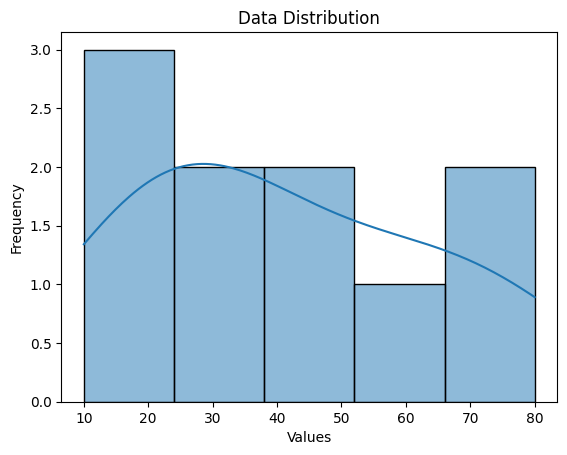

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data, kde=True)
#plt.hist(data)

plt.title("Data Distribution")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

**(e) On the same plot: Mark the mean, median, and mode using vertical lines and add legends, title,
and axis labels.**

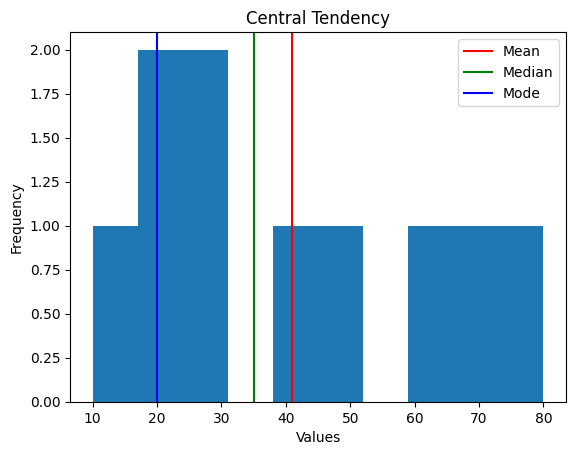

In [ ]:
mean = np.mean(data)
median = np.median(data)
mode = stats.mode(data, keepdims=True).mode[0]

plt.hist(data)

plt.axvline(mean, color='r', label='Mean')
plt.axvline(median, color='g', label='Median')
plt.axvline(mode, color='b', label='Mode')

plt.legend()
plt.title("Central Tendency")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.show()

# **Q3. Missing Value Handling :**

**(a) Load the Titanic dataset. Identify columns with missing values and Count the number of
missing values in each column.**

In [ ]:
df = pd.read_csv("titanic.csv")
print(df.isnull().sum())

PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age            32
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin          70
Embarked        0
dtype: int64


**(b) Replace missing values in the Age column using mean and median**

In [ ]:
df['Age_mean'] = df['Age'].fillna(df['Age'].mean())
df['Age_median'] = df['Age'].fillna(df['Age'].median())

**(c) Justify: When should mean be used and When is median a better choice?**



*   Mean is used when data is normally distributed

*   Median is used when data has outliers or skewed






# **Q4. Write a Python code to generate dataset with 5 features and 100 samples. Find the covariance matrix and also reduce it to 2 principal components.**

In [ ]:
from sklearn.decomposition import PCA

# Generate dataset
data = np.random.rand(100, 5)

# Covariance matrix
cov_matrix = np.cov(data, rowvar=False)
print(cov_matrix)

# PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(data)

print(reduced)

[[ 0.08493629 -0.00327491 -0.02164157 -0.00473296  0.0071488 ]
 [-0.00327491  0.08062569 -0.00971491  0.00070988 -0.00307937]
 [-0.02164157 -0.00971491  0.08821195 -0.0018953  -0.01262518]
 [-0.00473296  0.00070988 -0.0018953   0.07982501  0.00263551]
 [ 0.0071488  -0.00307937 -0.01262518  0.00263551  0.08044612]]
[[-0.13981261  0.49083489]
 [ 0.36298932  0.13945072]
 [-0.13112811 -0.69390375]
 [-0.42886763  0.0422547 ]
 [ 0.48489834  0.01145915]
 [ 0.25335202  0.03710354]
 [ 0.72925035 -0.18203065]
 [ 0.12339178 -0.03958662]
 [ 0.53826179 -0.17475329]
 [ 0.22337522 -0.34925625]
 [ 0.53268577 -0.31734645]
 [ 0.77841205 -0.32098619]
 [-0.03396617  0.17899743]
 [-0.0131839  -0.02959911]
 [-0.25250916  0.06544372]
 [ 0.42716027  0.27051886]
 [-0.01106788  0.37863277]
 [ 0.15506099 -0.05722547]
 [-0.04092683 -0.53040342]
 [ 0.16411776 -0.37252098]
 [ 0.20469722  0.63905829]
 [-0.30994359  0.22888775]
 [-0.01477656  0.07696219]
 [ 0.23480984 -0.34036443]
 [-0.45187202 -0.44641817]
 [-0.1967

# **Q5.Write Python code to print the probability distribution of X¡=130? (Given mean=120, standard deviation=10)**

In [ ]:
from scipy.stats import norm

mean=120
std=10

prob=norm.pdf(130,mean,std)
print("P(X=130):",prob)


P(X=130): 0.024197072451914336


# **Q6. Write Python code to print the interval probability between 110 to 130. (Given mean=120,standard deviation=10)**

In [ ]:
from scipy.stats import norm
mean=120
std=10
prob=norm.cdf(130,mean,std)-norm.cdf(110,mean,std)
print("Probability between 110 and 130:",prob)

Probability between 110 and 130: 0.6826894921370859


# **Q7. Write python code to standardize the given dataset: [25,30,45,50,60,76,82,88,98,110]**

In [ ]:
import numpy as np
data=np.array([25,30,45,50,60,76,82,88,98,110])

mean=np.mean(data)
std=np.std(data)

z_score=(data-mean)/std

print("Mean:",mean)
print("Standard Deviation:",std)
print("Standardized Data:",z_score)

Mean: 66.4
Standard Deviation: 27.401459815126636
Standardized Data: [-1.51086841 -1.32839638 -0.78098029 -0.59850826 -0.2335642   0.3503463
  0.56931273  0.78827917  1.15322323  1.5911561 ]


# **Q8. A garden has a sprinkler system and the grass may become wet due to either the sprinkler orrain. If the sprinkler is ON, the grass is likely to be wet. However, the grass may also becomewet due to rainfall.**

**Step 1: Define probabilities**

In [ ]:
# Prior probability
P_C = 0.2
P_notC = 1 - P_C

# Conditional probabilities
P_R_given_C = 0.8
P_R_given_notC = 0.1

P_S_given_C = 0.1
P_S_given_notC = 0.5

# Wet grass probabilities
def P_W_given_SR(S, R):
    if S == 0 and R == 0:
        return 0
    elif S == 0 and R == 1:
        return 0.8
    elif S == 1 and R == 0:
        return 0.9
    elif S == 1 and R == 1:
        return 0.99

**Step 2: Compute P(R) and P(S)**

In [ ]:
# Total probability of Rain
P_R = P_R_given_C * P_C + P_R_given_notC * P_notC

# Total probability of Sprinkler
P_S = P_S_given_C * P_C + P_S_given_notC * P_notC

**Step 3: Case 1 → P(W | R)**

In [ ]:
# Compute P(W | R = True)
P_W_given_R = 0

for S in [0, 1]:
    if S == 1:
        P_S_val = P_S
    else:
        P_S_val = 1 - P_S

    P_W_given_R += P_W_given_SR(S, 1) * P_S_val

print("P(W=True | R=True):", P_W_given_R)

P(W=True | R=True): 0.8798


**Step 4: Case 2 → P(W | S)**

In [ ]:
# Compute P(W | S = True)
P_W_given_S = 0

for R in [0, 1]:
    if R == 1:
        P_R_val = P_R
    else:
        P_R_val = 1 - P_R

    P_W_given_S += P_W_given_SR(1, R) * P_R_val

print("P(W=True | S=True):", P_W_given_S)

P(W=True | S=True): 0.9216000000000001


**Compute P(W)**

In [ ]:
P_W = 0

for S in [0, 1]:
    for R in [0, 1]:
        if S == 1:
            P_S_val = P_S
        else:
            P_S_val = 1 - P_S

        if R == 1:
            P_R_val = P_R
        else:
            P_R_val = 1 - P_R

        P_W += P_W_given_SR(S, R) * P_S_val * P_R_val

print("P(W=True):", P_W)

P(W=True): 0.4984320000000001


**Step 6: Case 3 → Diagnostic Inference**

**P(R | W)**

In [ ]:
P_R_given_W = (P_W_given_R * P_R) / P_W
print("P(R=True | W=True):", P_R_given_W)

P(R=True | W=True): 0.4236325115562404


**P(S | W)**

In [ ]:
P_S_given_W = (P_W_given_S * P_S) / P_W
print("P(S=True | W=True):", P_S_given_W)

P(S=True | W=True): 0.7765793528505393


***DISCUSSION***

*   Bayesian Network models dependency between variables
*   Marginalization is used to eliminate hidden variables
*   Bayes theorem helps infer hidden causes from observed evidence




# **Q9.Markov chain**

**(a) Compute the 3-day probability distribution of the stock movement.**

In [ ]:
import numpy as np
# Transition matrix (Up, Down, Stable)

T = np.array([
    [0.60, 0.25, 0.15],
    [0.30, 0.50, 0.20],
    [0.40, 0.20, 0.40]
], dtype=float)

states = ["Up", "Down", "Stable"]

# 1) 3-day distribution
pi0 = np.array([1.0, 0.0, 0.0])   # start from Up
T3 = np.linalg.matrix_power(T, 3)

pi3 = pi0 @ T3
print("3-day distribution (start=Up):")

for s, p in zip(states, pi3):
    print(f"{s}: {p:.6f}")


3-day distribution (start=Up):
Up: 0.468500
Down: 0.316250
Stable: 0.215250


**(b) Find the steady-state (stationary) distribution of the Markov chain.**

In [ ]:
pi = np.array([1,0,0], dtype=float)   # any valid initial distribution
tol = 1e-12
max_iters = 100000

for _ in range(max_iters):
  pi_next = pi @ T
  if np.max(np.abs(pi_next - pi)) < tol:
    break
  pi = pi_next
print("\nSteady state distribution:")
for s, p in zip(states, pi):
  print(f"{s}: {p:.9f}")
print("\nCheck(pi @ T):",(pi @ T))


Steady state distribution:
Up: 0.460176991
Down: 0.318584071
Stable: 0.221238938

Check(pi @ T): [0.46017699 0.31858407 0.22123894]


# **10.Aleatoric Uncertainity**

**(a) Explain why this dataset represent aleatory uncertainty.**



*  Dataset shows ALEATORIC UNCERTAINITY when there is inherent randomness in the outcome of experiment

* Noise term (ε ~ N(0,1) introduces randomness


**(b) Modify a neural network so that it predicts the probability distribution instead s single value.**

Given:
Y=2.7x+3+0.74ϵ, ϵ∼N(0,1)
This means:
*   Output has random noise (uncertainty)
*  A normal neural network predicts only a single value (point estimate),soWe need to predict a probability distribution

Instead of predicting,y=f(x)
We predict,Y(X∼N(μ(x),σ(x))

So the model outputs:
μ(x)mean & σ(x)standard deviation


**(c) Using tensorflow probability build a model that outputs
Y | X ∼ N (µ(x), σ(x))
where µ(x) is the predicted mean and σ(x) represents the aleatory uncertainty.**

In [ ]:
!pip -q install tf-keras tensorflow-probability

import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import tf_keras as keras

tfd = tfp.distributions

# 1) Create synthetic dataset (aleatory noise)

def create_dataset(n, x_range):
    # x ~ Uniform(low, high)
    x = tfd.Uniform(low=x_range[0],
                    high=x_range[1]).sample(n).numpy()[:, None].astype(np.float32)

    y_true = (2.7 * x + 3.0).astype(np.float32)

    # Aleatory noise (Normal)
    eps = tfd.Normal(loc=0.0, scale=1.0).sample(n).numpy()[:, None].astype(np.float32)

    y = (y_true + eps * 0.74 * x).astype(np.float32)

    return x, y, y_true

np.random.seed(42)
tf.random.set_seed(42)

x_train, y_train, y_true_train = create_dataset(2000, [-10, 10])

x_val, y_val, y_true_val = create_dataset(500, [-10, 10])

#Model
model = keras.Sequential([
    keras.layers.Dense(2, input_shape=(1,)),
    tfp.layers.DistributionLambda(
        lambda t: tfd.Normal(
            loc=t[..., :1],
            scale=0.3 + tf.abs(t[..., 1:])
        ))])
# Negative log-likelihood loss (because model outputs a distribution)
def neg_loglik(y_true, y_dist):
    return -y_dist.log_prob(y_true)

model.compile(optimizer="adam", loss=neg_loglik)

# Train
model.fit(x_train, y_train, validation_data=(x_val, y_val),
epochs=200, verbose=0)
print("Training complete.")

#------------------------------
# 3) Predict distribution
#------------------------------
x_test = np.linspace(-10, 10, 400, dtype=np.float32)[:, None]
pred_dist = model(x_test)
y_mean = pred_dist.mean().numpy()
y_std = pred_dist.stddev().numpy()
#print("Prediction Distribution", y_mean, y_std)

#------------------------------
# 4) Predicting new value
#------------------------------
test_points = np.array([[-8.0], [0.0], [8.0]],dtype=np.float32)
d=model(test_points)
print("\nPredictions:")

for xi, mu, sd in zip(test_points[:, 0], d.mean().numpy()[:, 0], d.stddev().numpy()[:, 0]):
    print(f"x={xi:>5.1f}  mean={mu:>8.3f}  std(aleatory)={sd:>8.3f}")

Training complete.

Predictions:
x= -8.0  mean= -18.461  std(aleatory)=   5.461
x=  0.0  mean=   3.003  std(aleatory)=   0.330
x=  8.0  mean=  24.467  std(aleatory)=   5.520
